### Import Libraries

In [51]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import random
from sklearn.metrics import confusion_matrix, recall_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from IPython.display import display, HTML
from scipy.stats import pearsonr

### Load & Preprocess Dataset

In [54]:
df = pd.read_csv('Datasets/bot_iot_5_preprocessed_dataset.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (3668522, 44)


,pkSeqID,stime,flgs,flgs_number,proto,proto_number,saddr,sport,daddr,dport,...,TnP_Per_Dport,AR_P_Proto_P_SrcIP,AR_P_Proto_P_DstIP,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DestIP,Pkts_P_State_P_Protocol_P_SrcIP,category
0,-0.787773,0.134602,-0.773071,-0.566552,0.897071,0.904945,-0.420811,-0.146527,1.406491,0.136538,...,0.096663,-0.039266,-0.069531,0.415281,0.715712,-0.031835,-0.034284,0.347883,0.493931,DoS
1,-0.787772,0.134602,-0.773071,-0.566552,0.897071,0.904945,-0.420811,-0.146474,1.406491,0.136538,...,0.096663,-0.039266,-0.069531,0.415281,0.715712,-0.031835,-0.034284,0.347883,0.493931,DoS
2,-0.787771,0.134602,-0.773071,-0.566552,0.897071,0.904945,-0.420811,-0.146421,1.406491,0.136538,...,0.096663,-0.039266,-0.069531,0.415281,0.715712,-0.031835,-0.034284,0.347883,0.493931,DoS
3,-0.787770,0.134602,-0.773071,-0.566552,0.897071,0.904945,-0.420811,-0.146368,1.406491,0.136538,...,0.096663,-0.039266,-0.069531,0.415281,0.715712,-0.031835,-0.034284,0.347883,0.493931,DoS
4,-0.787769,0.134602,-0.773071,-0.566552,0.897071,0.904945,-0.420811,-0.146316,1.406491,0.136538,...,0.096663,-0.039266,-0.069531,0.415281,0.715712,-0.031835,-0.034284,0.347883,0.493931,DoS


In [55]:
label_encoder = LabelEncoder()
df["category_encoded"] = label_encoder.fit_transform(df["category"])
y = df["category_encoded"]
X = df.drop(columns=["category", "category_encoded"])
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

### Genetic Algorithm Parameters

In [57]:
POPULATION_SIZE = 50
MAX_NO_IMPROVEMENT = 10
MAX_GENERATIONS = 100
a = 0.5  # weight factor for fitness

### Initial Population Creation

In [59]:
def create_initial_population(n_features, pop_size):
    return [np.random.randint(0, 2, n_features).tolist() for _ in range(pop_size)]

### Correlation-based Feature Selection

In [61]:
def compute_correlation_merit(X_subset, y):
    k = X_subset.shape[1]
    if k == 0:
        return 0

    # Feature-class correlation
    r_cf = [abs(pearsonr(X_subset.iloc[:, i], y)[0]) for i in range(k)]

    # Feature-feature correlation
    r_ff = []
    for i in range(k):
        for j in range(i + 1, k):
            corr = abs(pearsonr(X_subset.iloc[:, i], X_subset.iloc[:, j])[0])
            r_ff.append(corr)

    mean_r_cf = np.mean(r_cf)
    mean_r_ff = np.mean(r_ff) if r_ff else 0

    merit = (k * mean_r_cf) / np.sqrt(k + (k - 1) * mean_r_ff) if k > 1 else mean_r_cf
    return merit

### Fitness Function with Caching

In [63]:
fitness_cache = {}

def evaluate_individual(chromosome):
    key = tuple(chromosome)
    if key in fitness_cache:
        return fitness_cache[key]

    selected_indices = [i for i, bit in enumerate(chromosome) if bit == 1]
    if not selected_indices:
        fitness_cache[key] = 0
        return 0

    X_selected = X.iloc[:, selected_indices]
    X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.3, random_state=42)

    model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
    sensitivity = np.mean([cm[i, i] / np.sum(cm[i, :]) if np.sum(cm[i, :]) > 0 else 0 for i in range(len(cm))])
    specificity = np.mean([
        (np.sum(cm) - np.sum(cm[:, i]) - np.sum(cm[i, :]) + cm[i, i]) /
        (np.sum(cm) - np.sum(cm[i, :]) if np.sum(cm[i, :]) > 0 else 1) for i in range(len(cm))
    ])
    gmean = np.sqrt(sensitivity * specificity)

    merit_s = compute_correlation_merit(X_selected, y)

    fitness = a * merit_s + (1 - a) * gmean
    fitness_cache[key] = fitness
    return fitness

### Evaluate the fitness of the entire population

In [65]:
def fitness_evaluation(population):
    return [evaluate_individual(individual) for individual in population]

### Selection

In [67]:
def selection(parents):
    return random.sample(parents, 2)

### Crossover (Uniform)

In [69]:
def crossover(parent1, parent2):
    child1 = [parent1[i] if random.random() > 0.5 else parent2[i] for i in range(len(parent1))]
    child2 = [parent2[i] if random.random() > 0.5 else parent1[i] for i in range(len(parent1))]
    return child1, child2

### Mutation (40%)

In [71]:
def mutate(chromosome, rate=0.4):
    return [bit if random.random() > rate else 1 - bit for bit in chromosome]

### Reproduction

In [73]:
def create_children(parents, num_children):
    children = []
    while len(children) < num_children:
        p1, p2 = selection(parents)
        c1, c2 = crossover(p1, p2)
        children.extend([mutate(c1), mutate(c2)])
    return children[:num_children]

### Visualizations

In [75]:
def plot_fitness_and_comparison(parent_fitness, child_fitness):
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    sns.histplot(parent_fitness + child_fitness, kde=True, bins=10, ax=axs[0])
    axs[0].set_title("Fitness Distribution (Current Generation)")
    axs[0].set_xlabel("Fitness Score")
    axs[0].set_ylabel("Frequency")
    axs[0].grid(True)

    axs[1].boxplot([parent_fitness, child_fitness], labels=['Parents', 'Children'])
    axs[1].set_title("Parents vs Children Fitness Comparison")
    axs[1].set_ylabel("Fitness Score")
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

def plot_convergence(best_fitness, avg_fitness):
    plt.plot(best_fitness, label='Best')
    plt.plot(avg_fitness, label='Average', linestyle='--')
    plt.xlabel("Generation")
    plt.ylabel("Fitness")
    plt.title("GA Convergence Plot")
    plt.xticks(ticks=range(len(best_fitness)))
    plt.legend()
    plt.grid(True)
    plt.show()

### GA Main Loop

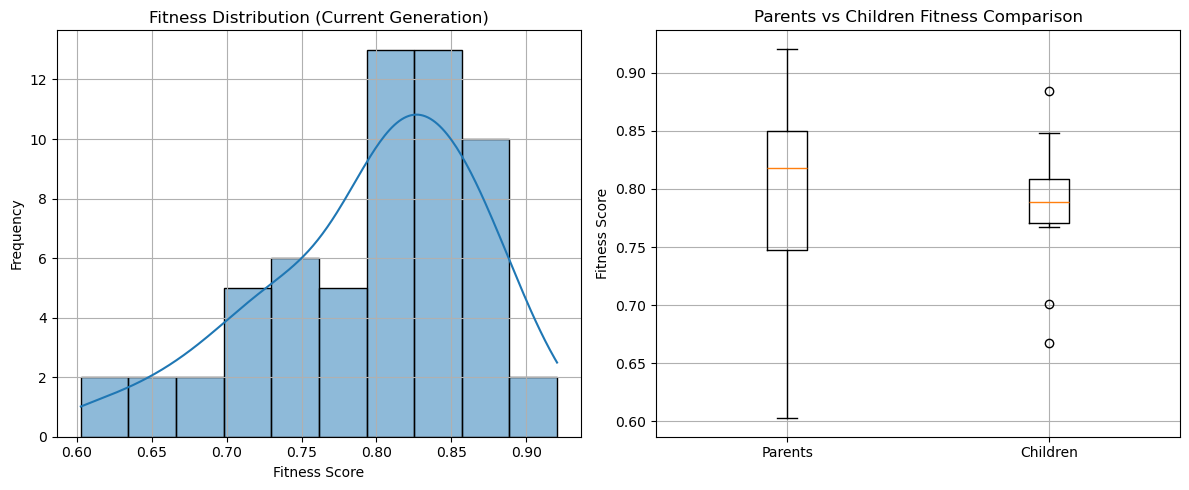

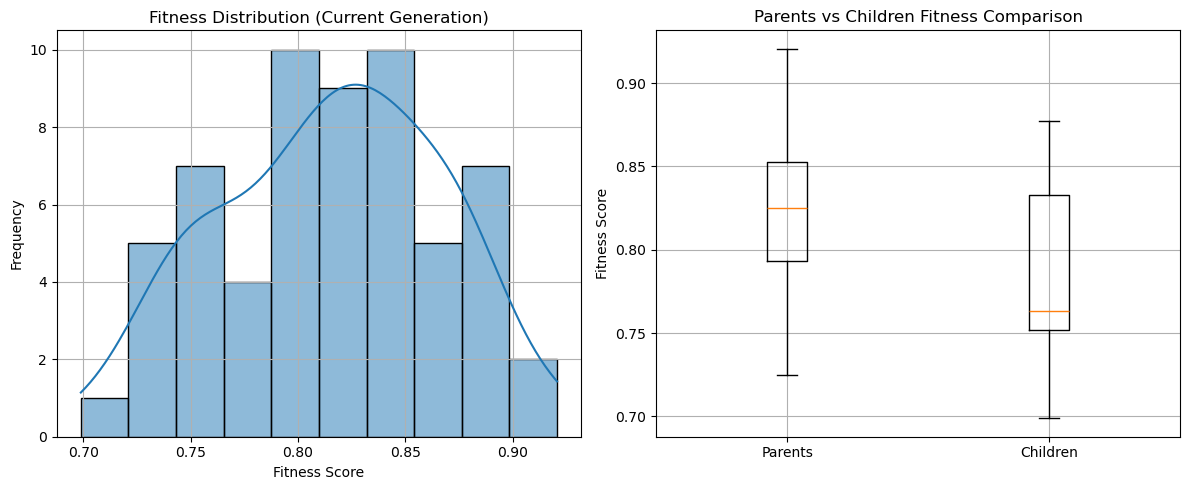

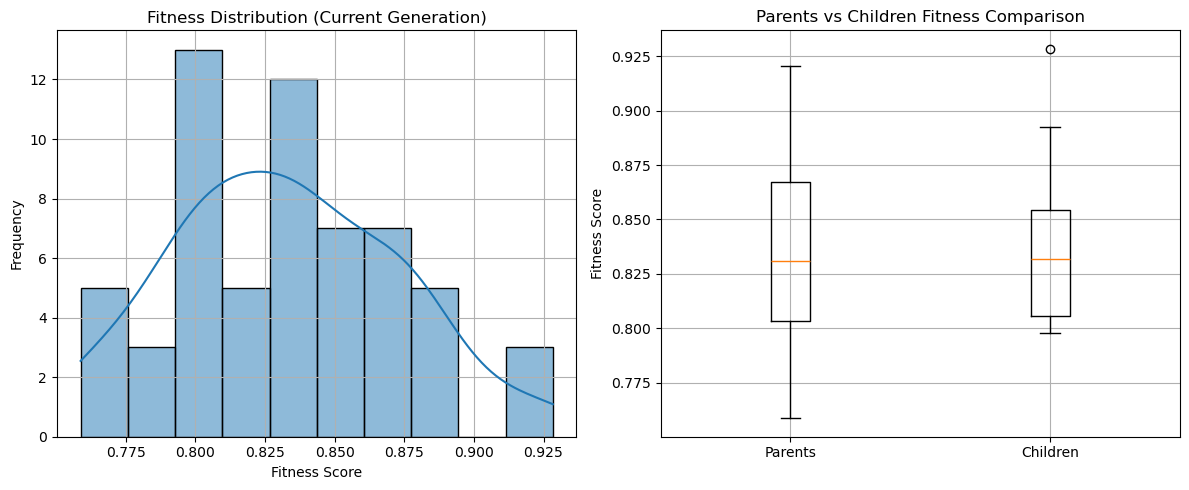

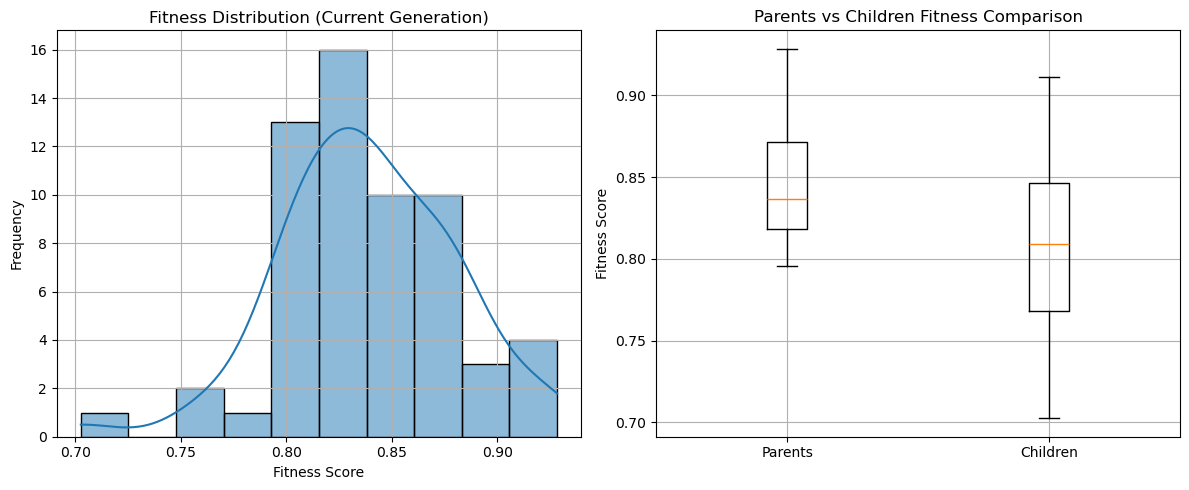

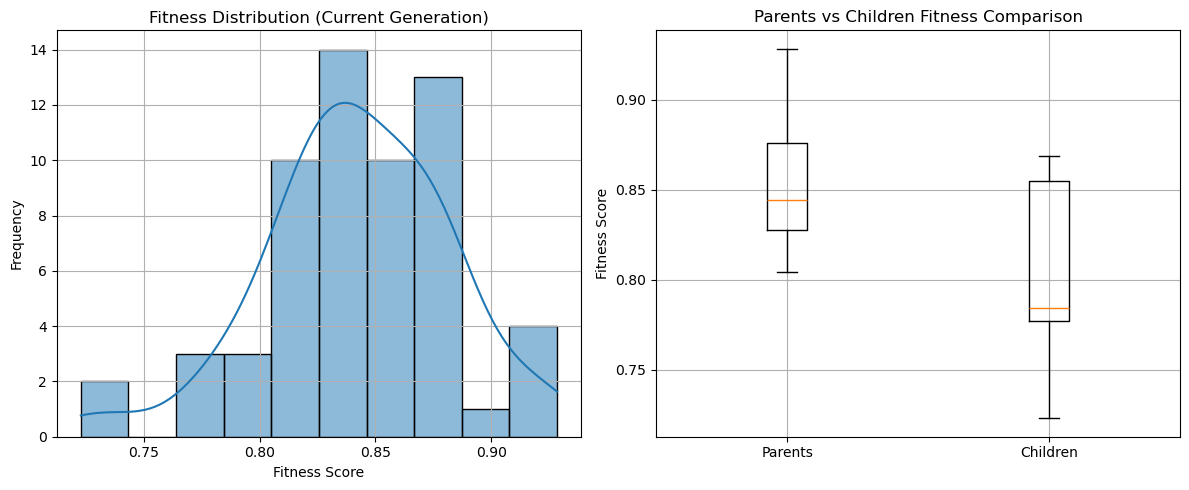

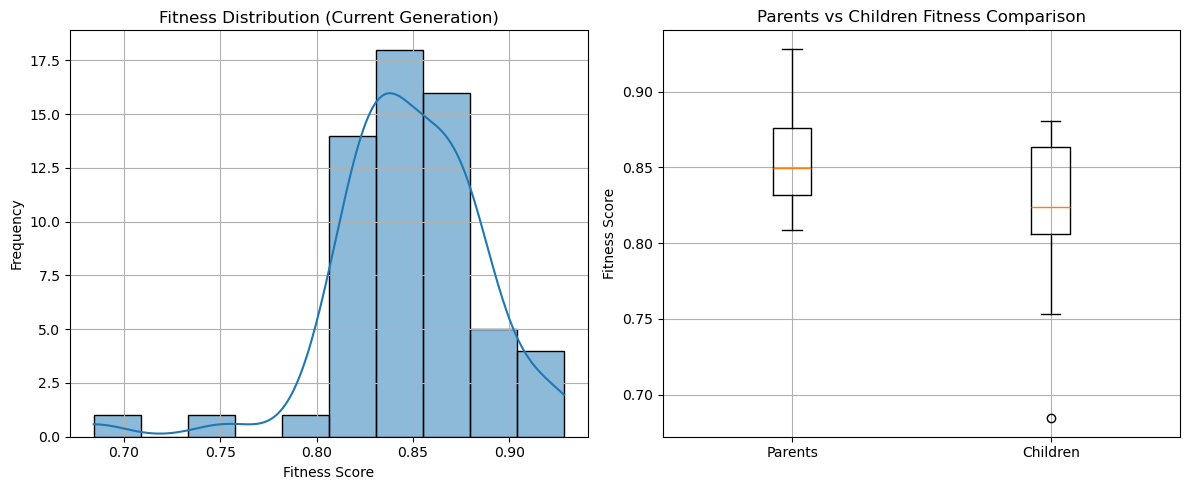

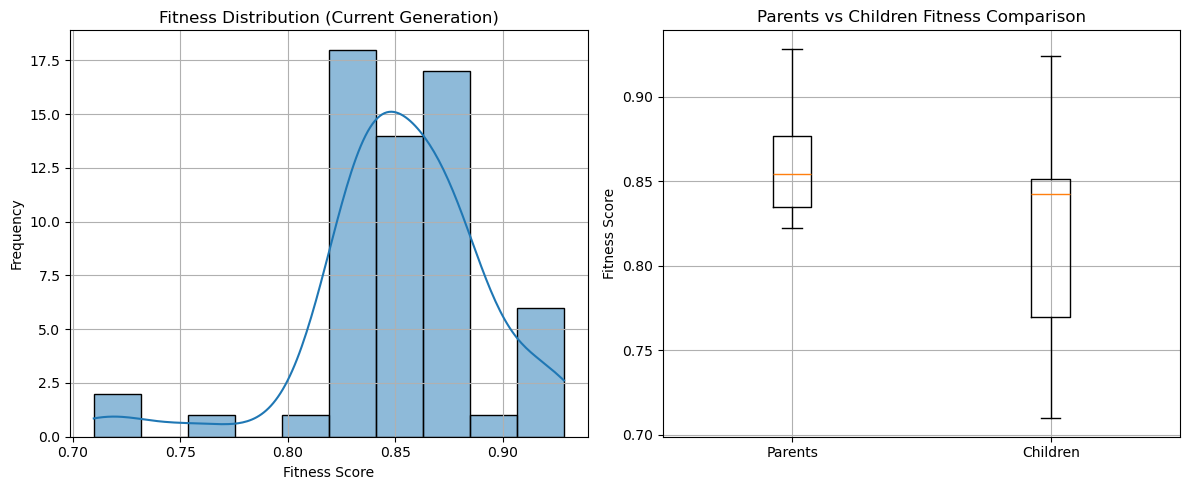

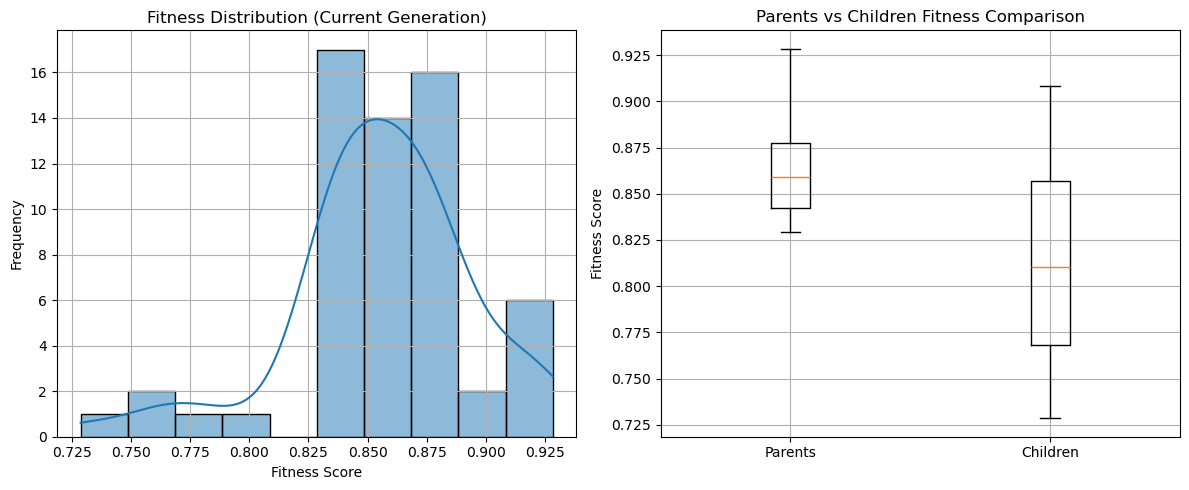

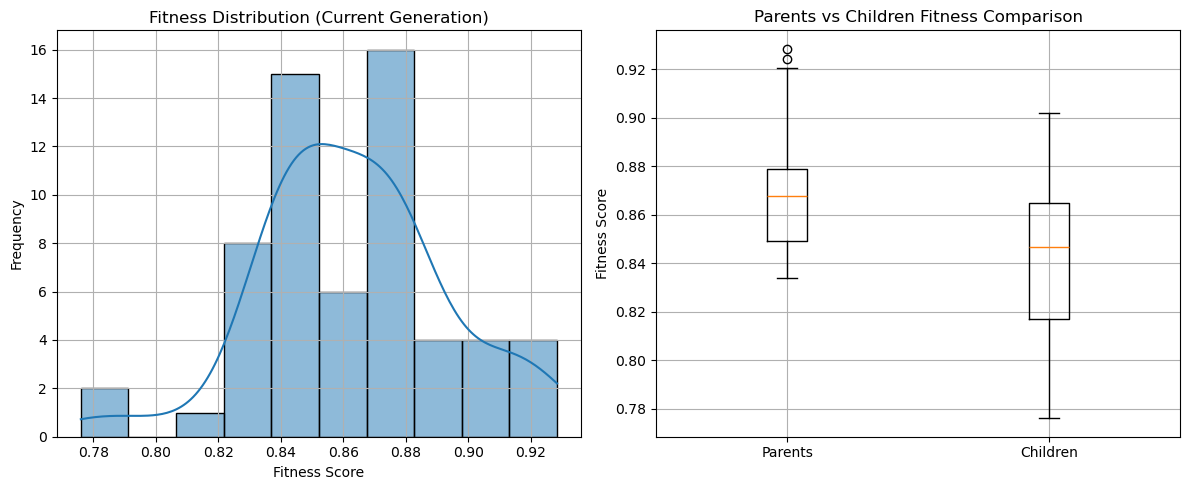

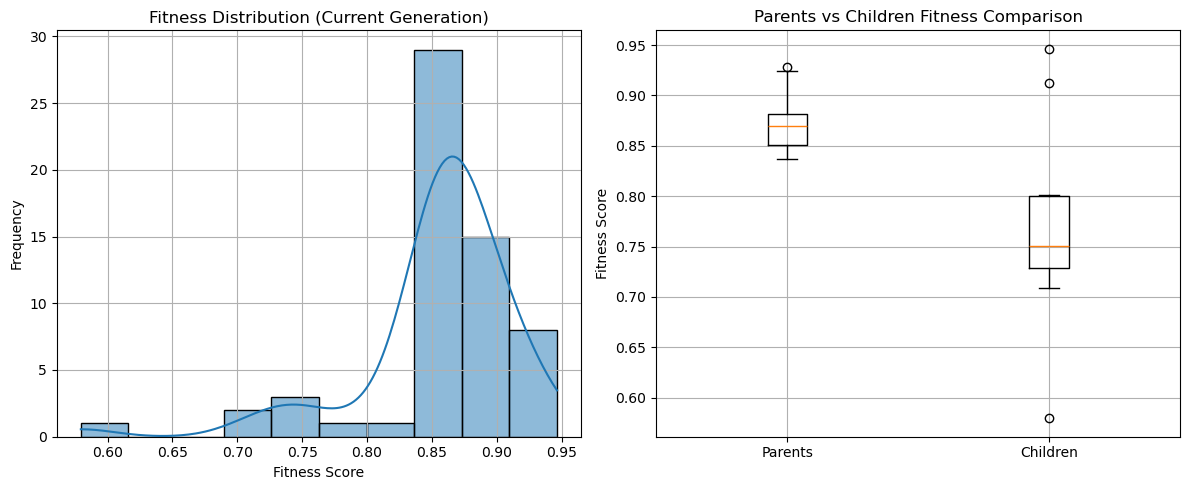

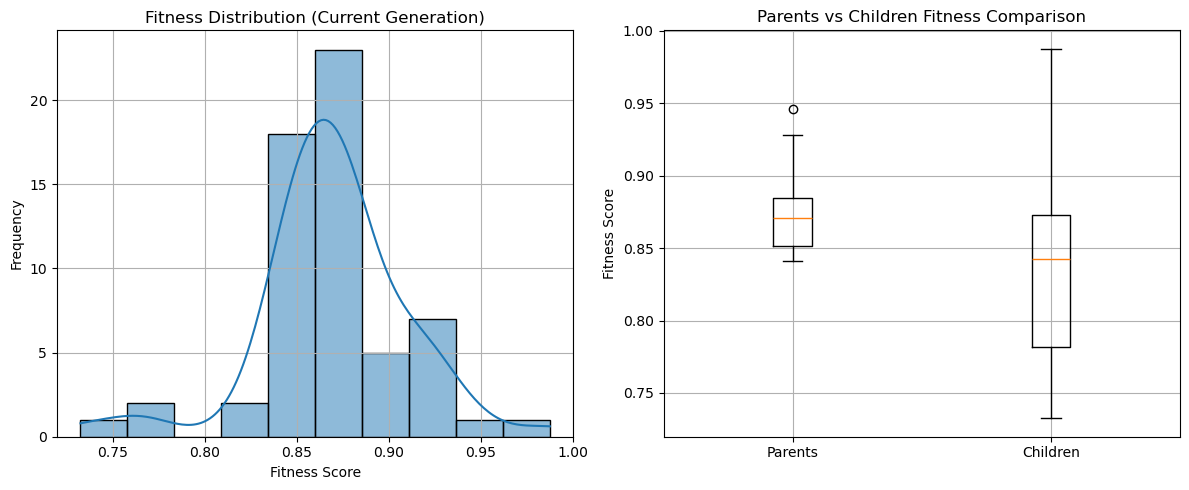

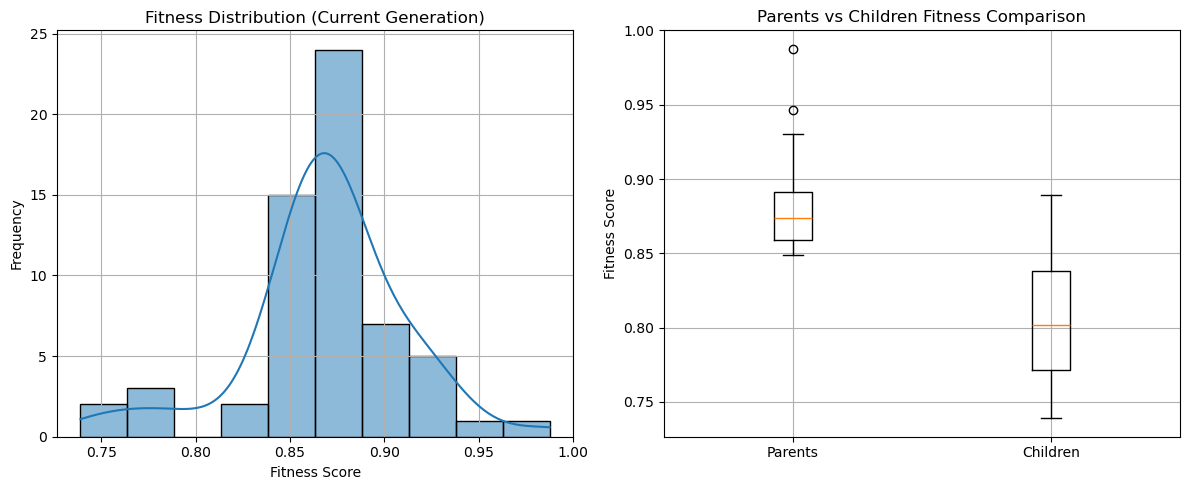

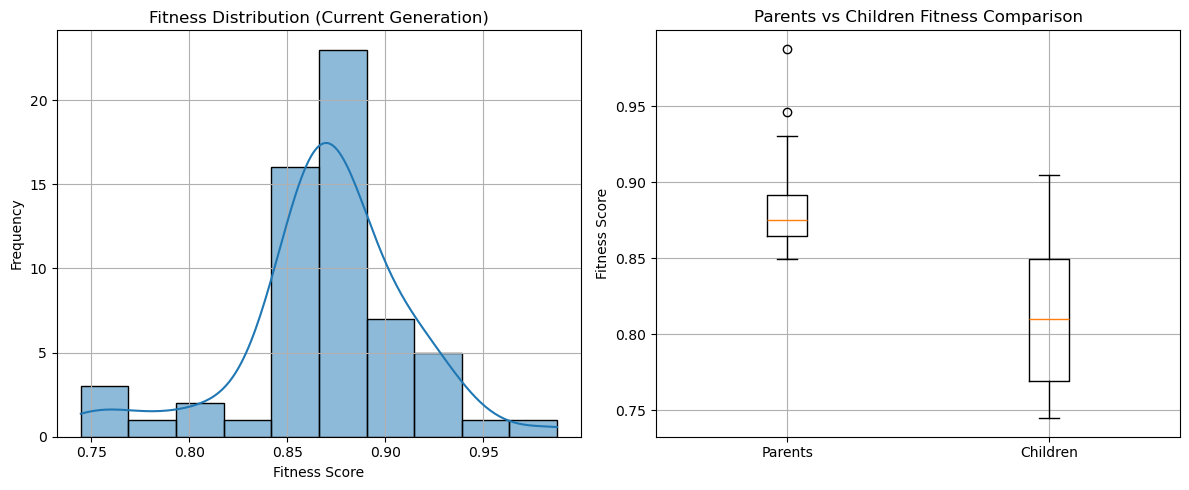

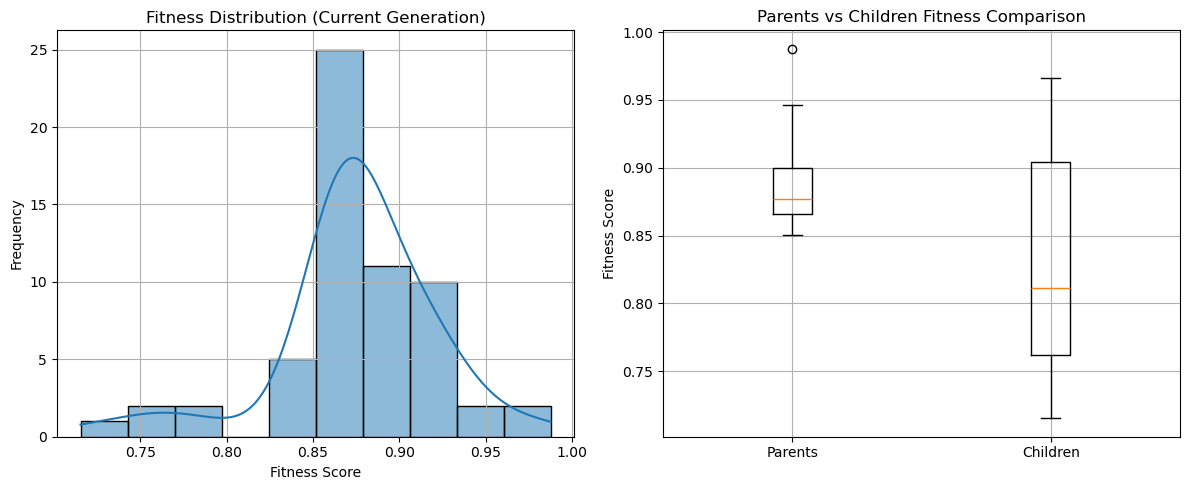

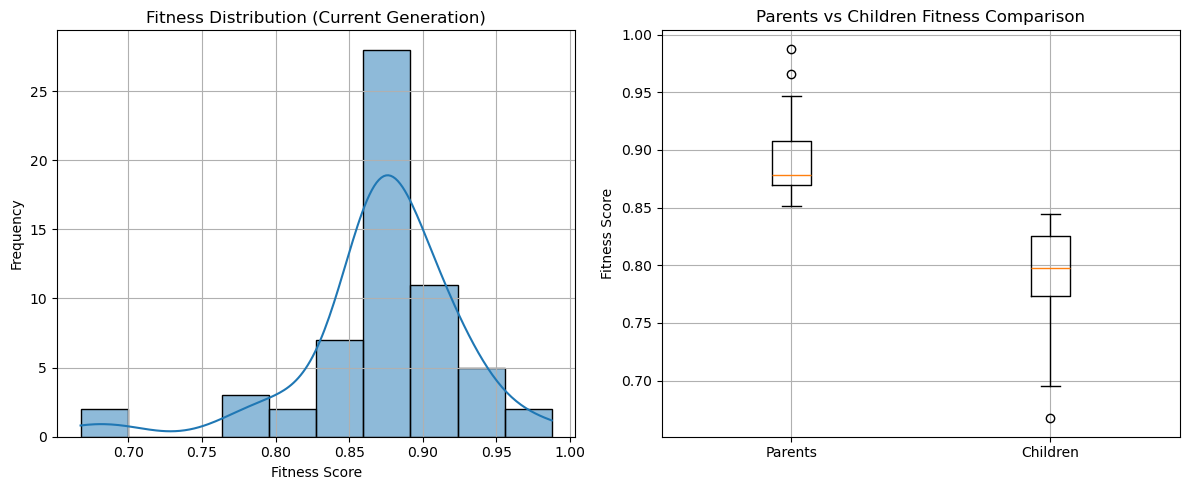

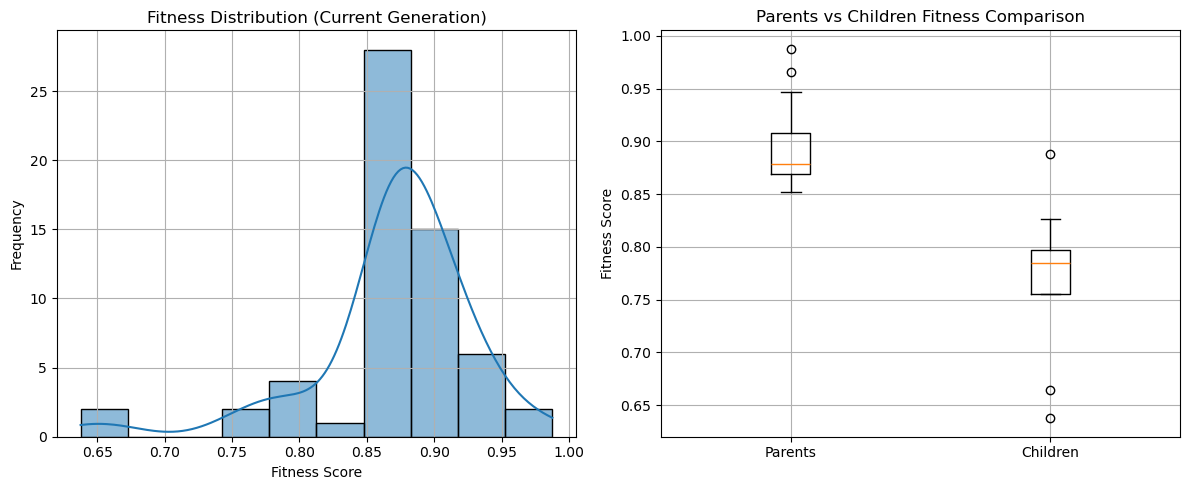

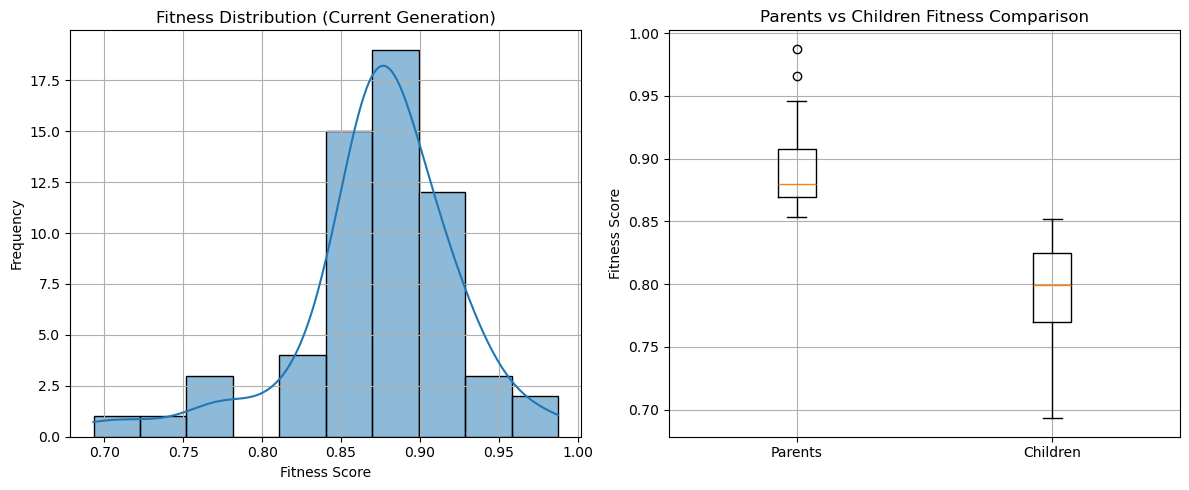

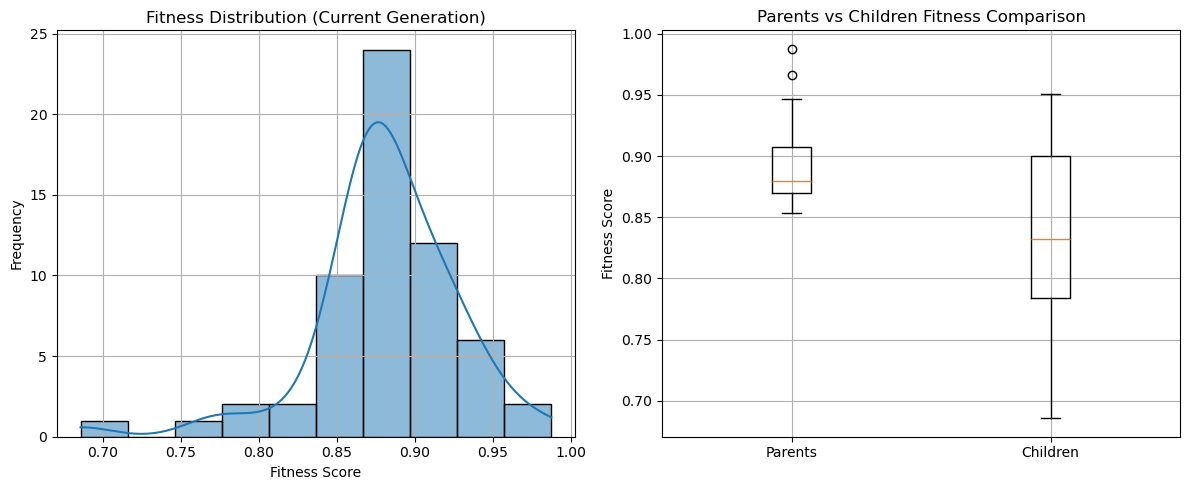

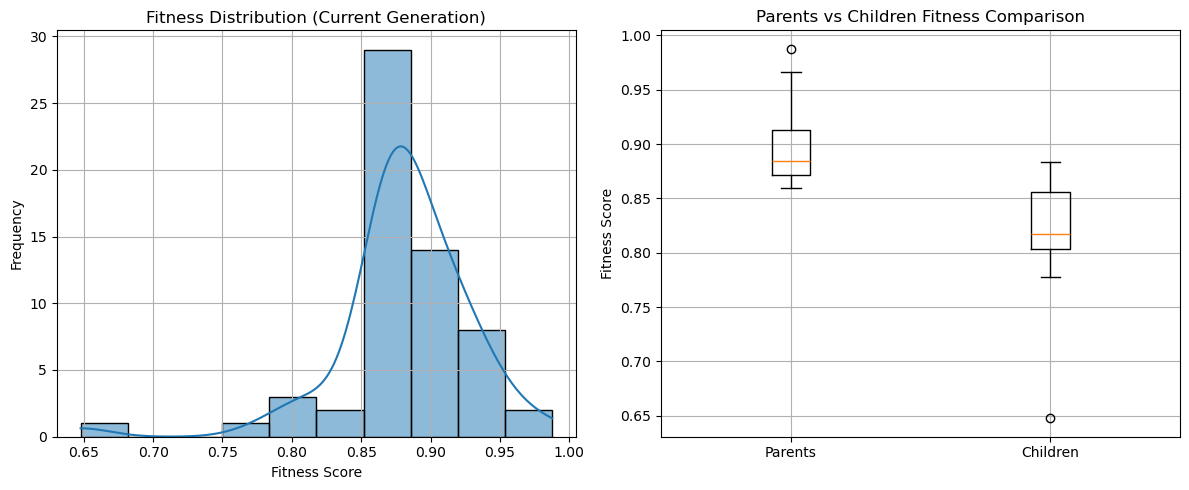

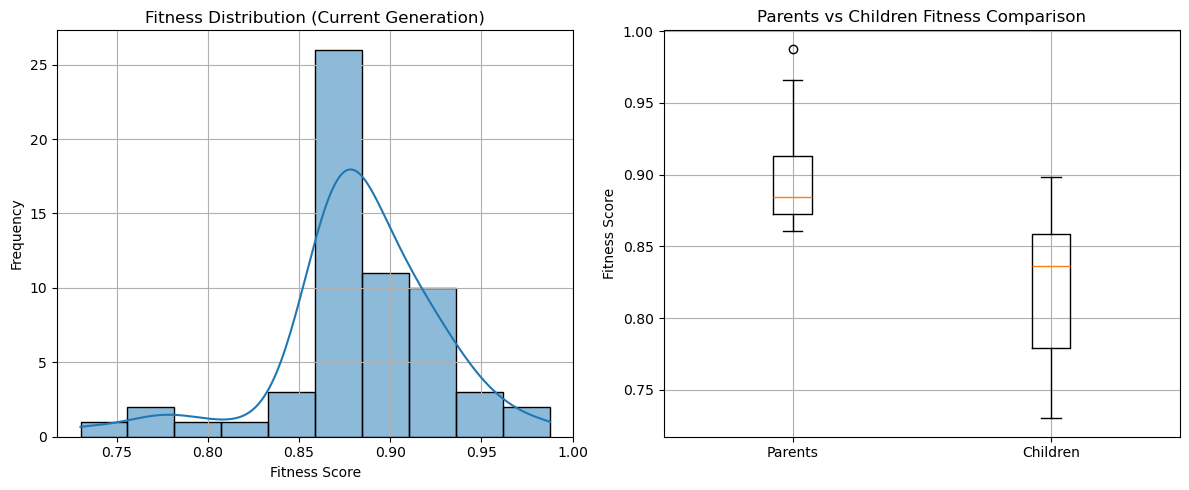

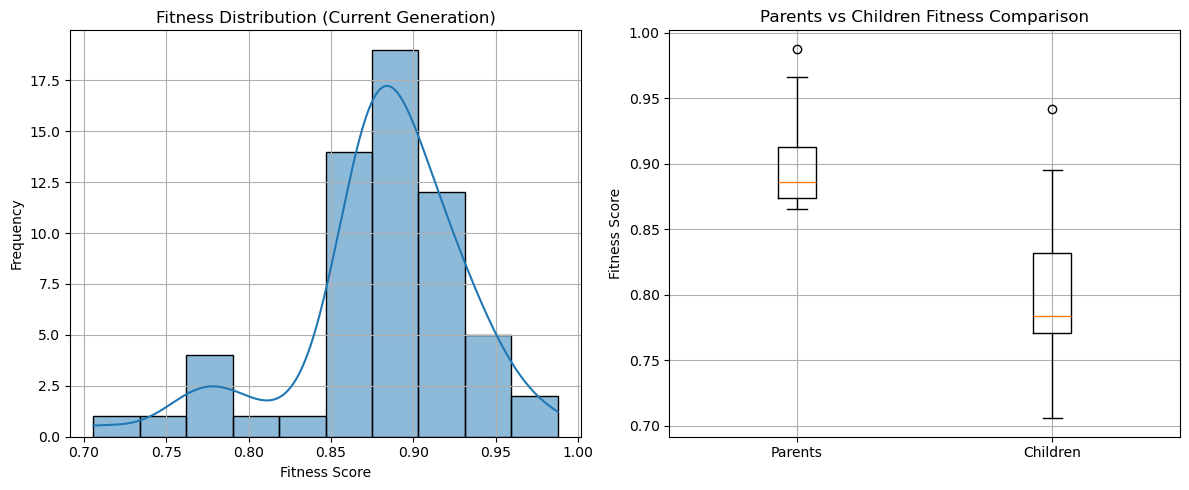

In [77]:
best_fitness_per_gen = []
avg_fitness_per_gen = []
population = create_initial_population(X.shape[1], POPULATION_SIZE)
best_score = 0
no_improvement = 0
generation = 0

while no_improvement < MAX_NO_IMPROVEMENT and generation < MAX_GENERATIONS:
    display(HTML(f"<h2 style='color: blue;'>Generation: {generation+1}</h2>"))

    fitness_scores = fitness_evaluation(population)
    avg_fitness = np.mean(fitness_scores)
    avg_fitness_per_gen.append(avg_fitness)

    num_children = int(0.2 * POPULATION_SIZE)
    children = create_children(population, num_children)

    if children:
        child_fitness = fitness_evaluation(children)
        parent_fitness = fitness_scores
        plot_fitness_and_comparison(parent_fitness, child_fitness)

    combined_population = population + children
    combined_fitness = fitness_evaluation(combined_population)
    sorted_combined = sorted(zip(combined_population, combined_fitness), key=lambda x: x[1], reverse=True)

    population = [individual for individual, _ in sorted_combined[:POPULATION_SIZE]]
    current_best = sorted_combined[0][1]
    best_fitness_per_gen.append(current_best)

    if current_best > best_score:
        best_score = current_best
        no_improvement = 0
    else:
        no_improvement += 1

    generation += 1


### Extract Best Chromosome + Feature Subset

In [79]:
final_fitness_scores = fitness_evaluation(population)
best_index = np.argmax(final_fitness_scores)
best_chromosome = population[best_index]
selected_features = X.columns[[i for i, bit in enumerate(best_chromosome) if bit == 1]]
print(selected_features)

Index(['pkSeqID', 'stime', 'proto_number', 'saddr', 'sport', 'daddr', 'dport',
       'pkts', 'ltime', 'stddev', 'min', 'max', 'sbytes', 'rate', 'drate',
       'TnBPDstIP', 'AR_P_Proto_P_SrcIP', 'AR_P_Proto_P_DstIP',
       'N_IN_Conn_P_DstIP', 'N_IN_Conn_P_SrcIP', 'AR_P_Proto_P_Sport',
       'AR_P_Proto_P_Dport'],
      dtype='object')


In [80]:
avg_fitness = np.mean(final_fitness_scores)
avg_fitness_per_gen.append(avg_fitness)

best_fitness_per_gen.append(final_fitness_scores[best_index])

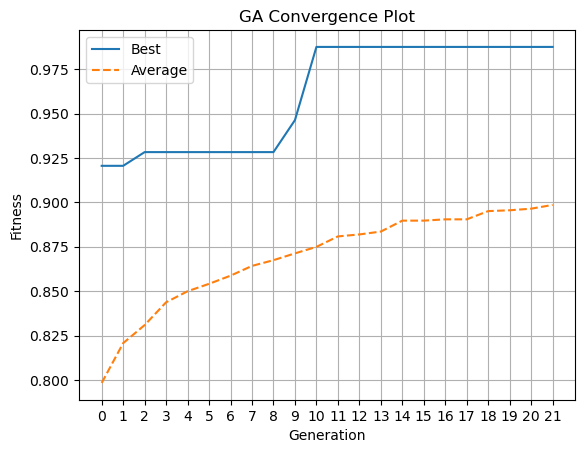

In [81]:
plot_convergence(best_fitness_per_gen, avg_fitness_per_gen)

In [82]:
X_selected_final = X[selected_features]
# Convert encoded y back to category labels
y_categories = label_encoder.inverse_transform(y)

# Create a new DataFrame with category labels
df_labels = pd.DataFrame({'category': y_categories})

# Concatenate X_selected_final with the decoded labels
df_final = pd.concat([X_selected_final.reset_index(drop=True), df_labels], axis=1)

df_final.head()

,pkSeqID,stime,proto_number,saddr,sport,daddr,dport,pkts,ltime,stddev,...,rate,drate,TnBPDstIP,AR_P_Proto_P_SrcIP,AR_P_Proto_P_DstIP,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,category
0,-0.787773,0.134602,0.904945,-0.420811,-0.146527,1.406491,0.136538,0.002371,0.13462,-1.075065,...,-0.030892,-0.00739,-0.021299,-0.039266,-0.069531,0.415281,0.715712,-0.031835,-0.034284,DoS
1,-0.787772,0.134602,0.904945,-0.420811,-0.146474,1.406491,0.136538,0.002371,0.13462,-1.075077,...,-0.030892,-0.00739,-0.021299,-0.039266,-0.069531,0.415281,0.715712,-0.031835,-0.034284,DoS
2,-0.787771,0.134602,0.904945,-0.420811,-0.146421,1.406491,0.136538,0.002371,0.13462,-1.075077,...,-0.030892,-0.00739,-0.021299,-0.039266,-0.069531,0.415281,0.715712,-0.031835,-0.034284,DoS
3,-0.787770,0.134602,0.904945,-0.420811,-0.146368,1.406491,0.136538,0.002371,0.13462,-1.075123,...,-0.030892,-0.00739,-0.021299,-0.039266,-0.069531,0.415281,0.715712,-0.031835,-0.034284,DoS
4,-0.787769,0.134602,0.904945,-0.420811,-0.146316,1.406491,0.136538,0.002371,0.13462,-1.075077,...,-0.030892,-0.00739,-0.021299,-0.039266,-0.069531,0.415281,0.715712,-0.031835,-0.034284,DoS


In [84]:
# Save the combined DataFrame to a CSV file
df_final.to_csv("Datasets/bot_iot_5_ga_feature_selection_dataset.csv", index=False)
print("Dataframe saved to a CSV file")

Dataframe saved to a CSV file


In [85]:
X_selected_final = X[selected_features]
X_train, X_test, y_train, y_test = train_test_split(X_selected_final, y, test_size=0.3, random_state=42)
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_labels = label_encoder.inverse_transform(y_pred)
y_test_labels = label_encoder.inverse_transform(y_test)

In [86]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train, model.predict(X_train.values))
test_accuracy = accuracy_score(y_test, y_pred)

print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")


Training Accuracy: 1.0000
Testing Accuracy: 1.0000


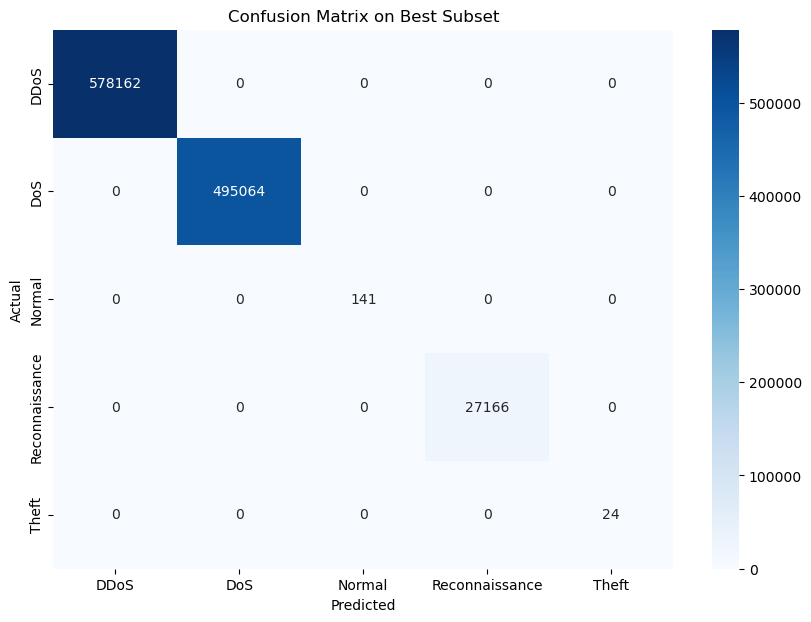

In [87]:
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=label_encoder.classes_)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix on Best Subset")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [88]:
print("\nClassification Report:\n")
print(classification_report(y_test_labels, y_pred_labels, target_names=label_encoder.classes_))


Classification Report:

                precision    recall  f1-score   support

          DDoS       1.00      1.00      1.00    578162
           DoS       1.00      1.00      1.00    495064
        Normal       1.00      1.00      1.00       141
Reconnaissance       1.00      1.00      1.00     27166
         Theft       1.00      1.00      1.00        24

      accuracy                           1.00   1100557
     macro avg       1.00      1.00      1.00   1100557
  weighted avg       1.00      1.00      1.00   1100557

